In [1]:
import os
import sys
sys.path.append(os.path.join(os.path.dirname(os.getcwd()), 'src'))

from pathlib import Path
import cv2
import pickle
import numpy as np
import matplotlib.pyplot as plt
import math
import json
from datetime import date
plt.rcParams["figure.figsize"] = (24,18)

from ultralytics import YOLO
from utils import *

In [2]:
model_path = os.path.join(os.path.dirname(os.getcwd()), 'models')
model = YOLO(os.path.join(model_path, "yolov8n.pt"))

In [3]:
data_path = os.path.join(os.path.dirname(os.getcwd()), 'data')
vid_name =  'real_test'

True


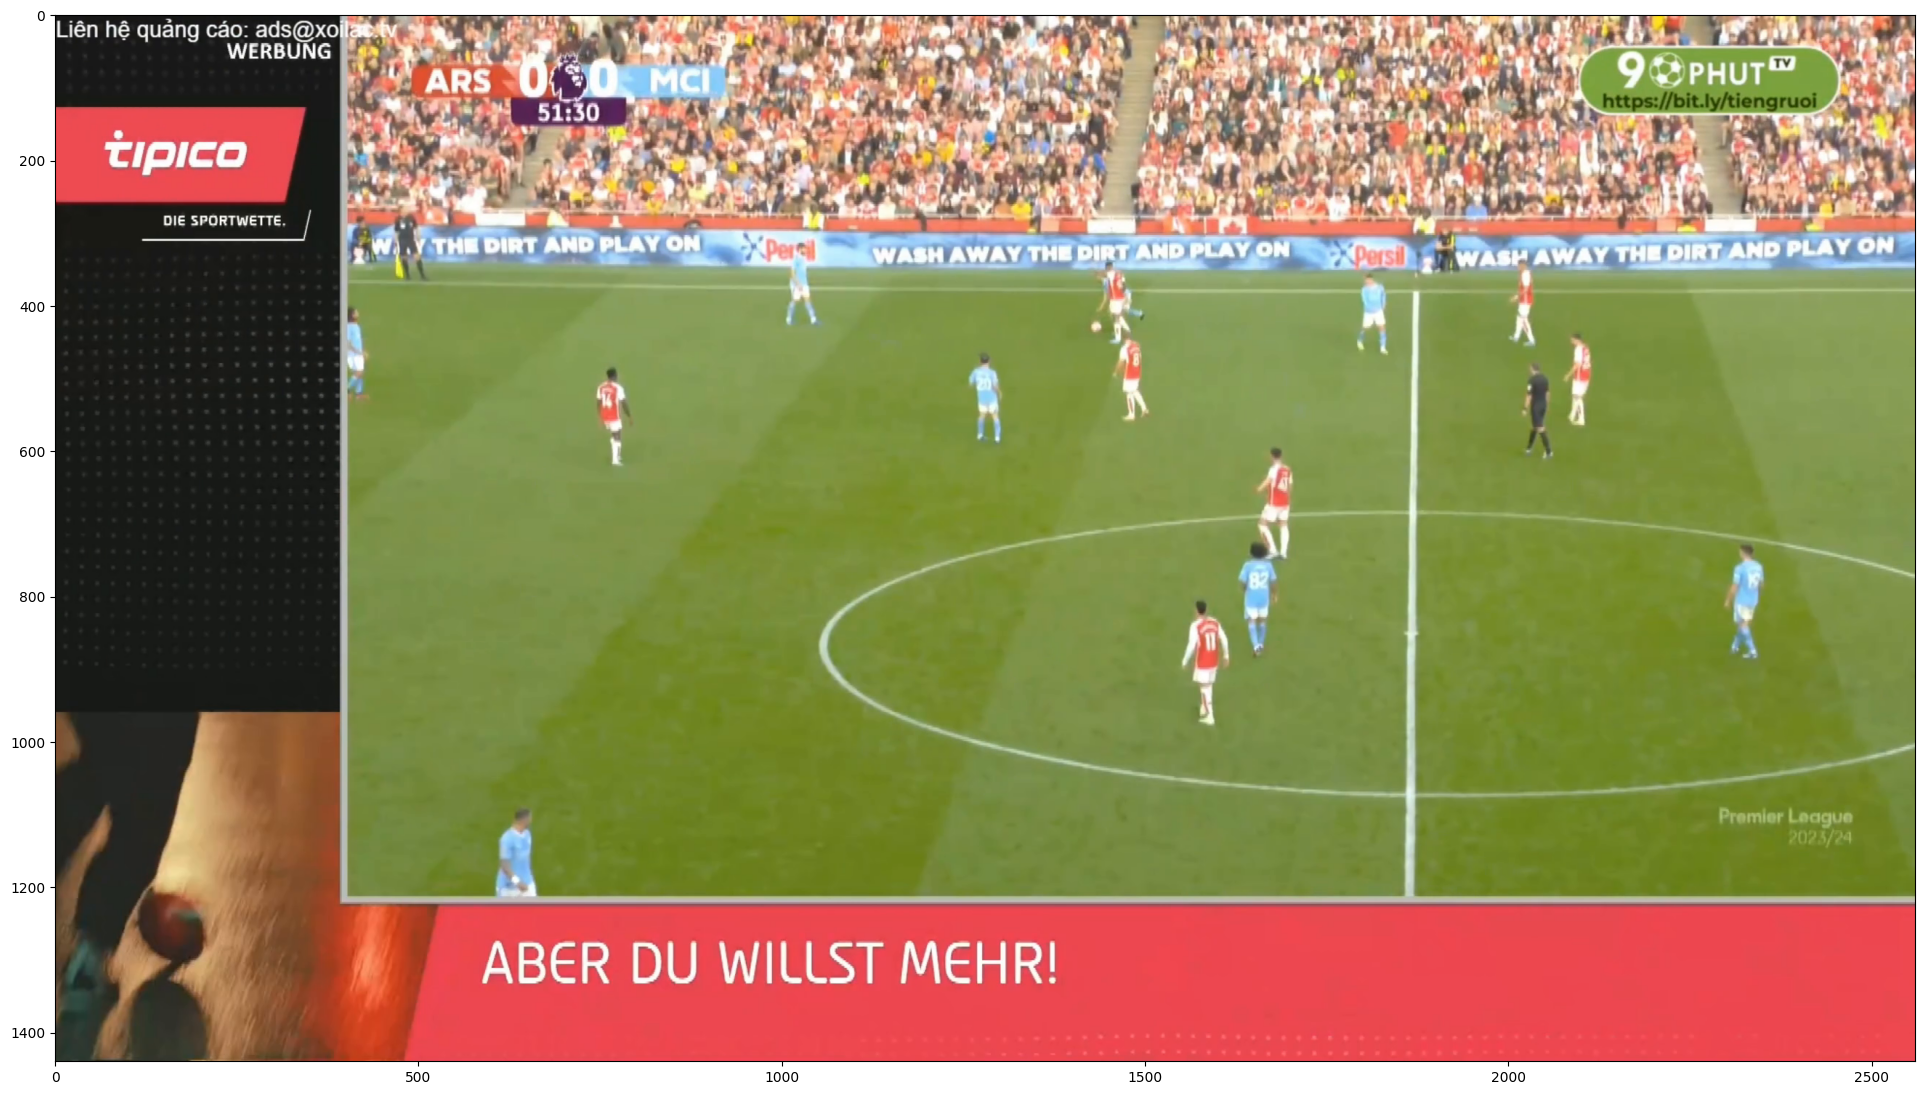

In [92]:
images_path = os.path.join(data_path, 'images' + '/' + vid_name)
print(os.path.exists(images_path))
images_path
image_path = os.path.join(images_path, os.listdir(images_path)[11])

rgb_image = cv2.imread(image_path, cv2.COLOR_BGR2RGB)

plt.figure()
plt.imshow(rgb_image[:,:,::-1])

[[   0 1439]
 [   0  206]
 [2559  206]
 [2559 1439]]


/tmp/ipykernel_28670/31316505.py:17: DeprecationWarning: `np.int0` is a deprecated alias for `np.intp`.  (Deprecated NumPy 1.24)
  rect = np.int0(cv2.boxPoints(cv2.minAreaRect(contours)))


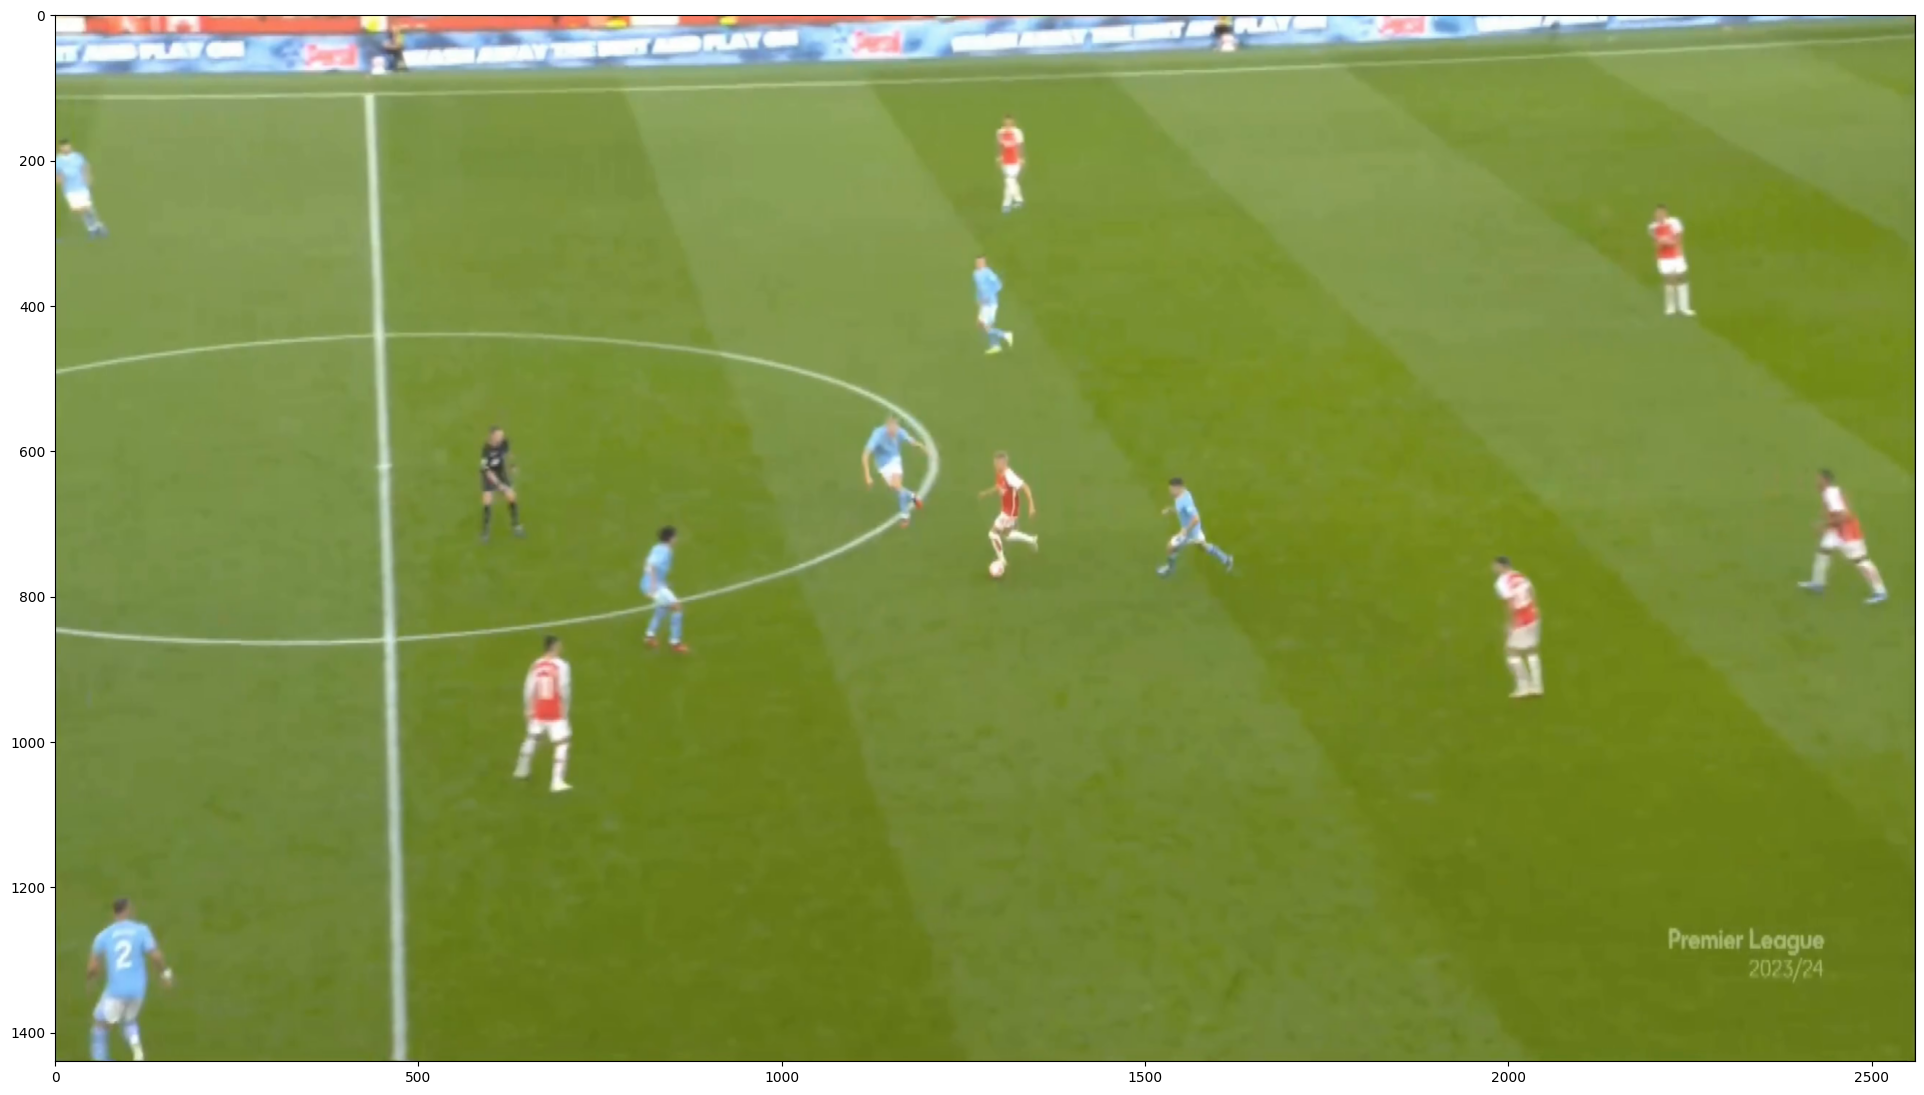

In [11]:
hsv_image = cv2.cvtColor(rgb_image, cv2.COLOR_BGR2HSV)
lower_green = np.array([35, 20, 50])
upper_green = np.array([90, 255, 255])

mask_green = cv2.inRange(hsv_image, lower_green, upper_green)
result = cv2.bitwise_and(hsv_image, hsv_image, mask=mask_green)
temp = cv2.cvtColor(result, cv2.COLOR_HSV2RGB)
h, w, _ = result.shape
_, green, _ = cv2.split(temp)

#ret, thresh = cv2.threshold(temp, 150, 255, cv2.THRESH_BINARY)

contours, hierarchy = cv2.findContours(image=green, mode=cv2.RETR_EXTERNAL,
                                      method=cv2.CHAIN_APPROX_NONE)

contours = max(contours, key=cv2.contourArea)
rect = np.int0(cv2.boxPoints(cv2.minAreaRect(contours)))
print(rect)
min_y, max_y = sorted(np.unique(rect[:, 1]))
min_x, max_x = sorted(np.unique(rect[:, 0]))
#cv2.polylines(img=temp, pts=[contours], isClosed=False, color=(255, 0, 0), thickness=5)
cv2.polylines(img=temp, pts=[rect],
                             isClosed=True, color=(255, 0, 0), thickness=5)

plt.imshow(temp[min_y:max_y, min_x:max_x])

# Crop the image
result = cv2.resize(result[min_y:max_y, min_x:max_x], (w, h))
rgb_image = cv2.resize(rgb_image[min_y:max_y, min_x:max_x], (w, h))
plt.imshow(rgb_image[:,:,::-1])

In [104]:
from sklearn.cluster import KMeans

# Import images
images_path = os.path.join(data_path, 'images' + '/' + vid_name)
print(os.path.exists(images_path))
image_path = os.path.join(images_path, os.listdir(images_path)[15])
rgb_image = cv2.imread(image_path, cv2.COLOR_BGR2RGB)


## pitch seg
hsv_image = cv2.cvtColor(rgb_image, cv2.COLOR_BGR2HSV)
lower_green = np.array([35, 20, 50])
upper_green = np.array([90, 255, 255])

mask_green = cv2.inRange(hsv_image, lower_green, upper_green)
result = cv2.bitwise_and(hsv_image, hsv_image, mask=mask_green)
temp = cv2.cvtColor(result, cv2.COLOR_HSV2RGB)
h, w, _ = result.shape
_, green, _ = cv2.split(temp)

#ret, thresh = cv2.threshold(temp, 150, 255, cv2.THRESH_BINARY)

contours, hierarchy = cv2.findContours(image=green, mode=cv2.RETR_EXTERNAL,
                                      method=cv2.CHAIN_APPROX_NONE)

contours = max(contours, key=cv2.contourArea)
rect = np.int0(cv2.boxPoints(cv2.minAreaRect(contours)))
min_y, max_y = sorted(np.unique(rect[:, 1]))
min_x, max_x = sorted(np.unique(rect[:, 0]))
#cv2.polylines(img=temp, pts=[contours], isClosed=False, color=(255, 0, 0), thickness=5)
cv2.polylines(img=temp, pts=[rect],
                             isClosed=True, color=(255, 0, 0), thickness=5)

# Crop the image
result = cv2.resize(result[min_y:max_y, min_x:max_x], (w, h))
rgb_image = cv2.resize(rgb_image[min_y:max_y, min_x:max_x], (w, h))

## run the model

results = model.predict(rgb_image)
boxes = results[0].boxes
# Compute hue of grass
grass_average = rgb_image[:,:,::-1].mean(axis=0).mean(axis=0)
# Assignment 
assignment=[]
for crop in boxes.xyxy:
    (startX, startY, endX, endY) = coord = crop.cpu().detach().int().tolist()
    cropped = rgb_image[startY:endY,startX:endX]
    test_crop = cropped[:,:,::-1].copy()
    result = []
    for row_idx in range(cropped.shape[0]):
        for col_idx in range(cropped.shape[1]):        
            current_color = test_crop[row_idx][col_idx]
            if sum(abs(current_color - grass_average)) > 60:
                  result.append(current_color)
    final_color = np.mean(result,axis = 0)
    assignment.append(final_color)
kmeans = KMeans(n_clusters=3)
s=kmeans.fit(assignment)
labels=kmeans.labels_
print(labels)



/tmp/ipykernel_28670/3086063662.py:27: DeprecationWarning: `np.int0` is a deprecated alias for `np.intp`.  (Deprecated NumPy 1.24)
  rect = np.int0(cv2.boxPoints(cv2.minAreaRect(contours)))

0: 384x640 12 persons, 1 ball, 52.6ms
Speed: 2.5ms preprocess, 52.6ms inference, 0.8ms postprocess per image at shape (1, 3, 384, 640)


True
[2 1 0 1 2 2 0 1 2 1 0 1 0]


/home/huy-ng/Project/Football-analysis/.venv/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


In [ ]:
def export_coco_dataset_from_prediction(data_path, folder_name, model_name="yolov8n.pt"):
    model_path = os.path.join(os.path.dirname(os.getcwd()), 'models')
    print(model_path)
    model = YOLO(os.path.join(model_path, model_name))

    images_path = os.path.join(data_path, 'images' + '/' + folder_name)

    dest_path = os.path.join(data_path, 'coco_datasets' + '/' + folder_name)
    if not os.path.exists(dest_path):
        os.mkdir(dest_path)

    dest_images_path = os.path.join(dest_path, 'images')
    if not os.path.exists(dest_images_path):
        os.mkdir(dest_images_path)

    dest_coco_path = os.path.join(dest_path, 'annotations')
    if not os.path.exists(dest_coco_path):
        os.mkdir(dest_coco_path)

    
    coco_dict ={}
    frame_id = 1
    obj_id = 1
    categories_dict = [{"id" : 1, "name" : "person", "supercategory" : None},
                    {"id" : 2, "name" : "ball", "supercategory" : None}]

    creation_date = date.today()
    year = creation_date.year
    coco_info = {
        'contributor': 'Khoa Nguyen, Huy Nguyen',
        'description': folder_name,
        'url': '',
        'version': 0,
        'date_created': str(creation_date),
        'year': year,
    }

    images = []
    annotations = []


    for image_name in os.listdir(images_path):
        frame = os.path.join(images_path, image_name)
        # Get image shape for COCO dataset:
        h, w, _ = cv2.imread(frame, cv2.IMREAD_UNCHANGED).shape

        # Set image metadata for COCO dataset:
        metadata = {"height" : h,
                    "width" : w,
                    "id" : frame_id,
                    "file_name": image_name}
        images.append(metadata)

        # Run YOLOv8 inference on the frame
        results = model(frame, classes=[0, 32])

        # Copy original image to coco dataset destination
        shutil.copy(frame, os.path.join(dest_images_path, image_name))

        # Write information to coco dataset:
        boxes = results[0].boxes
        for box in boxes:
            (startX, startY, endX, endY) = box.xyxy.cpu().detach().int().tolist()[0]
            class_id = box.cls[0].item()
            bbox = {"id" : obj_id,
                    "image_id" : frame_id,
                    "category_id" : 1 if class_id == 0.0 else 2,
                    "segmentation" : [],
                    "bbox" : [startX, startY, endX-startX, endY-startY],
                        "area" : (endX-startX) * (endY-startY),
                    "iscrowd" : 0}
            
            annotations.append(bbox)
            obj_id += 1
        frame_id += 1


    coco_dict["info"] = coco_info
    coco_dict["license"] = {'name': folder_name,
                            'id': '',
                            'url': ''}
    coco_dict["categories"] = categories_dict
    coco_dict["images"] = images
    coco_dict["annotations"] = annotations

    with open(os.path.join(dest_coco_path, 'instances_default.json'), 'w') as coco:
        json.dump(coco_dict, coco)